In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold

In [2]:
df = pd.read_csv("data_with_embedding.csv")
print(df.shape)

(1008, 147)


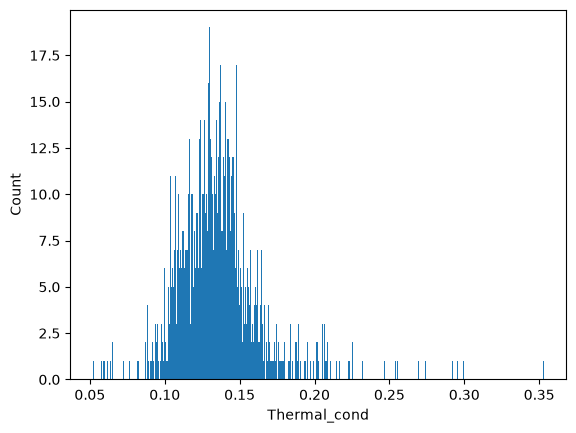

In [3]:
plt.hist(df["Thermal_cond"], bins=500)
plt.xlabel("Thermal_cond")
plt.ylabel("Count")
plt.show()

In [4]:
target = "Thermal_cond"

df = df[df[target] <= 0.4].reset_index(drop=True)

X = df.drop(columns=["Name", "SMILES", "Fingerprints", target])

y = df[target]

y_log = np.log1p(y)

print(X.shape)
print(y.shape)

""" print((y > 0).sum())
print((y > 0.2).sum())
print((y > 0.25).sum())
print((y > 0.3).sum())
print((y > 0.4).sum())
print((y > 0.5).sum())  """

(1008, 143)
(1008,)


' print((y > 0).sum())\nprint((y > 0.2).sum())\nprint((y > 0.25).sum())\nprint((y > 0.3).sum())\nprint((y > 0.4).sum())\nprint((y > 0.5).sum())  '

In [5]:
y_bins = pd.qcut(y,q=5,labels=False,duplicates="drop")

from sklearn.model_selection import StratifiedKFold

outer_bins = pd.qcut(
    y,
    q=6,
    labels=False,
    duplicates="drop"
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=3407
)

param_grid = { "n_estimators": [500, 600, 700,800, 900, 1000],
               "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1], 
               "reg_lambda": [1, 2, 3, 4], 
               "reg_alpha": [0, 0.1, 0.3, 0.5], 
               "max_depth": [2, 3, 4, 5, 6], 
               "min_child_weight": [3, 4, 5, 6], 
               "subsample": [0.6, 0.7, 0.8, 0.9, 1], 
               "colsample_bytree": [0.6, 0.7, 0.8, 0.9], 
               "gamma": [0, 0.1, 0.3, 0.5], 
               "scale_pos_weight": [1, 2, 3, 4] }

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

r2_list = []
mae_list = []
rmse_list = []

all_true = []
all_pred = []

weight = 2

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, outer_bins), 1):

    print(f"\n Fold {fold}:")

    # Outer Train / Test

    X_train_raw = X.iloc[train_idx]
    X_test_raw = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    y_train_log = np.log1p(y_train)

    # Feature Selection

    selector = VarianceThreshold(threshold=0)

    X_train = selector.fit_transform(X_train_raw)

    X_test = selector.transform(X_test_raw)

    # Sample Weight

    threshold = y_train.quantile(0.95)

    weights = np.where(y_train >= threshold,weight,1)

    # Inner CV

    y_train_bins = pd.qcut(y_train, q=5, labels=False, duplicates="drop")

    search = RandomizedSearchCV(

        estimator=XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),

        param_distributions=param_grid,

        n_iter=50,

        scoring="r2",

        cv=list(inner_cv.split(X_train, y_train_bins)),

        random_state=3407,

        n_jobs=-1

    )

    search.fit(X_train, y_train_log, sample_weight=weights)

    best_model = search.best_estimator_

    print(search.best_params_)

    y_pred_log = best_model.predict(X_test)

    y_pred = np.expm1(y_pred_log)


    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2_list.append(r2)

    mae_list.append(mae)

    rmse_list.append(rmse)

    all_true.extend(y_test)

    all_pred.extend(y_pred)


    print(
        f"Fold {fold}: "
        f"R²={r2:.4f}, "
        f"MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}"
    )

print("\nAverage")

print(f"Mean R²   : {np.mean(r2_list):.4f}  (± {np.std(r2_list):.4f})")
print(f"Mean MAE  : {np.mean(mae_list):.4f}  (± {np.std(mae_list):.4f})")
print(f"Mean RMSE : {np.mean(rmse_list):.4f} (± {np.std(rmse_list):.4f})")


 Fold 1:
{'subsample': 0.8, 'scale_pos_weight': 4, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 900, 'min_child_weight': 4, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
Fold 1: R²=0.7499, MAE=0.0095, RMSE=0.0140

 Fold 2:
{'subsample': 1, 'scale_pos_weight': 4, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Fold 2: R²=0.7435, MAE=0.0085, RMSE=0.0148

 Fold 3:


ValueError: min() arg is an empty sequence

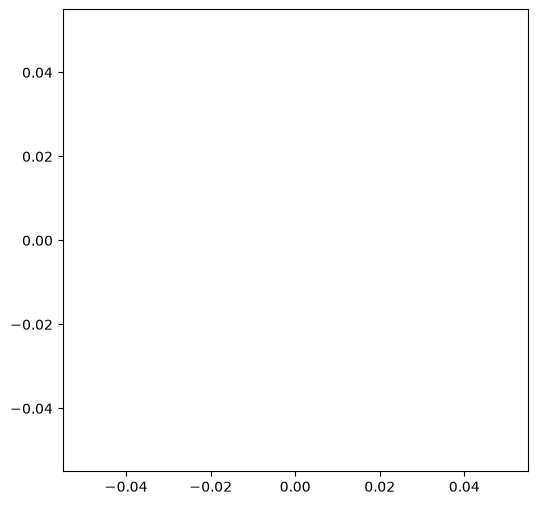

In [8]:
plt.figure(figsize=(6, 6))

plt.scatter(all_true, all_pred, alpha=0.7)

min_val = min(min(all_true), min(all_pred))
max_val = max(max(all_true), max(all_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    label="Ideal"
)

plt.xlabel("True Thermal Conductivity")
plt.ylabel("Predicted Thermal Conductivity")
plt.title(f"XGBoost Prediction (Mean R² : {np.mean(r2_list):.4f}  (± {np.std(r2_list):.4f}))")
plt.legend()

plt.show()

In [9]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

weights = np.where( y >= y.quantile(0.95), weight, 1)

y_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop"
)

search = RandomizedSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=param_grid,

    n_iter=50,

    scoring="r2",

    cv=list(
        inner_cv.split(
            X_selected,
            y_bins
        )
    ),

    random_state=3407,

    n_jobs=-1
)

search.fit(X_selected, np.log1p(y), sample_weight=weights)

print(search.best_params_)

{'subsample': 0.8, 'scale_pos_weight': 4, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 900, 'min_child_weight': 4, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
